グラフを 'experiment_plan_fixed_start.png' として保存しました。


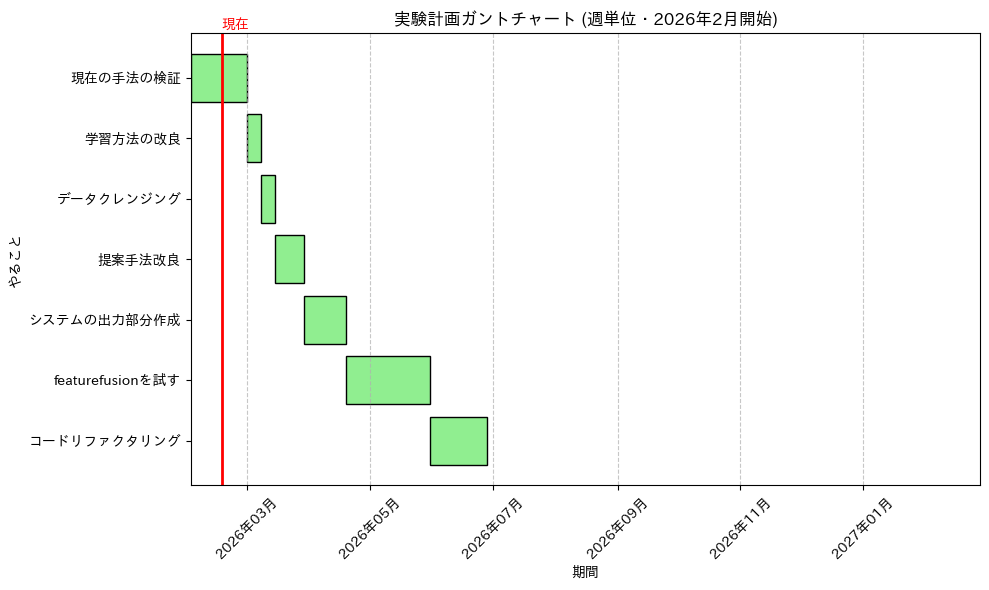

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import japanize_matplotlib  # 日本語フォントを正しく表示するため

# 1. 週単位のCSVデータの読み込み
df = pd.read_csv("plan_weeks.csv")

# 2. 期間の設定
# 始まりを2026年2月1日に固定する
start_date = datetime(2026, 2, 1)
# 終わりは2027年2月末
end_date = datetime(2027, 2, 28)

# 3. 各タスクの開始日と終了日を計算（直列に進むと仮定）
current_date = start_date
start_dates = []
end_dates = []

for duration in df['Duration_weeks']:
    start_dates.append(current_date)
    # timedeltaで weeks= を指定して週数分の日付を加算する
    task_end = current_date + timedelta(weeks=duration)
    end_dates.append(task_end)
    current_date = task_end

df['Start'] = start_dates
df['End'] = end_dates

# 4. グラフ（ガントチャート）の作成
fig, ax = plt.subplots(figsize=(10, 6))

# タスクを逆順にして、上から下へと時系列が進むように表示させる
tasks = df['Task'][::-1]
starts = df['Start'][::-1]
ends = df['End'][::-1]

# 棒グラフの描画 (幅は日単位で計算して描画)
for task, start, end in zip(tasks, starts, ends):
    ax.barh(task, (end - start).days, left=start, color='lightgreen', edgecolor='black')

# ==========================================
# ★ 追加: 現在の日にちを赤い縦線（棒）で示す
# ==========================================
now_date = datetime.now()
ax.axvline(x=now_date, color='red', linestyle='-', linewidth=2, label='現在の日時')
# 分かりやすいように「現在」というテキストも線のそばに添えます
ax.text(now_date, ax.get_ylim()[1], '現在', color='red', verticalalignment='bottom', fontweight='bold')


# 5. X軸の期間設定とフォーマット
ax.set_xlim(start_date, end_date) # 2026年2月から2027年2月まで
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2)) # 2ヶ月ごとの目盛り
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y年%m月"))
plt.xticks(rotation=45)

# グラフの装飾
ax.set_xlabel("期間")
ax.set_ylabel("やること")
ax.set_title("実験計画ガントチャート (週単位・2026年2月開始)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# 6. グラフを画像として保存する
plt.savefig("experiment_plan_fixed_start.png", dpi=300)
print("グラフを 'experiment_plan_fixed_start.png' として保存しました。")